<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 3</h3>
    <h5>Ejercicio 2</h5>
        <p>Docente: Rodrigo Del Rosso<p>
        <p>Asistente: Sebastián Calcagno<p>
</div>

Algunos Métodos Simples de Forecasting

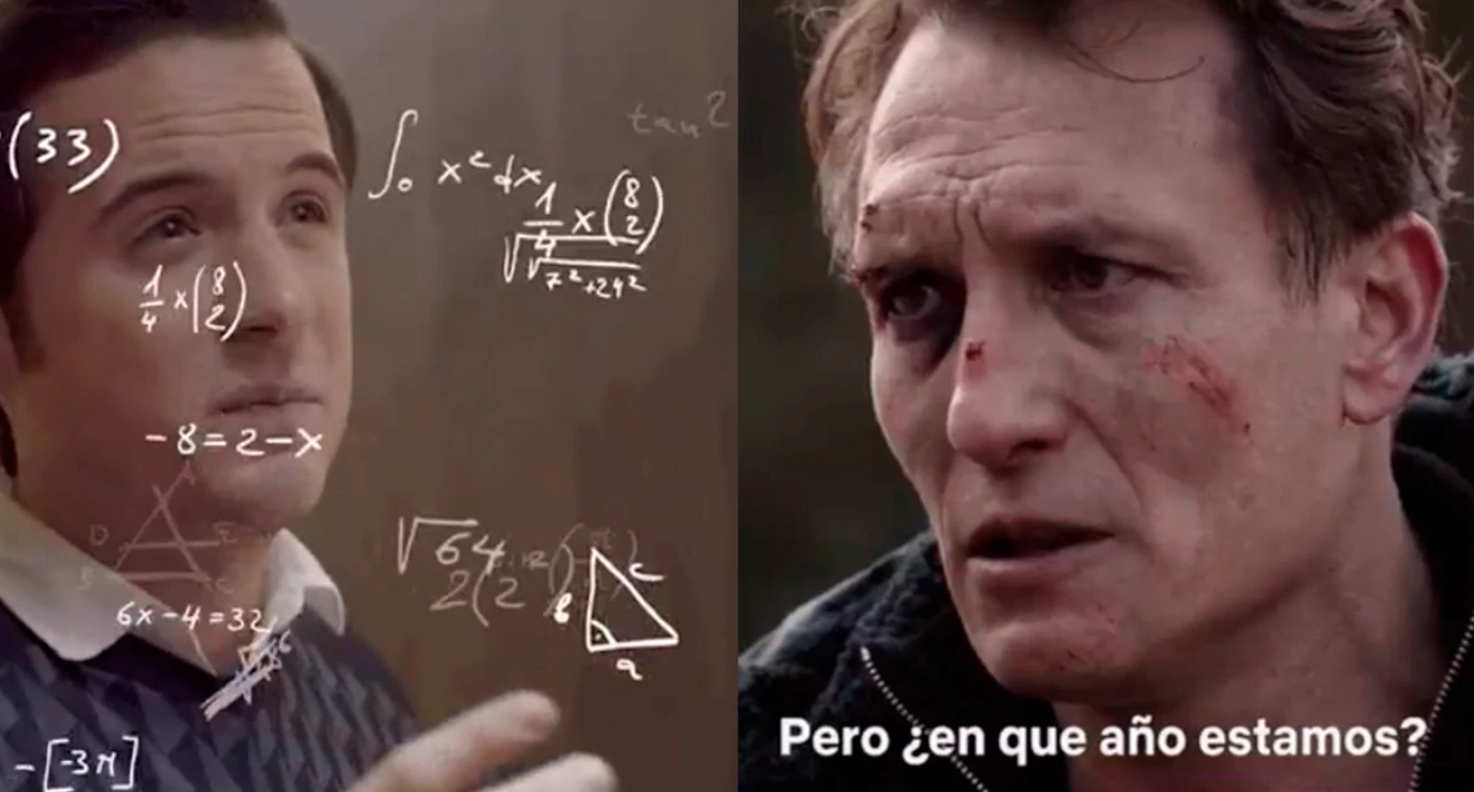

# Preparacion inicial del codigo para ambos Casos

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
import math

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [ ]:
'''
Datos del Ejemplo 1.
Se trata de las busquedas en Google de "Buenos Aires, entre las fechas 2020-08-16	y  2025-08-17	. Los datos son semanales .

Fuente = https://trends.google.es/trends/explore?date=today%205-y&gprop=news&q=%2Fm%2F01ly5m&hl=es

'''

url='https://raw.githubusercontent.com/sebcalcagno/AnalisisSeriesTemporales/refs/heads/main/BsAsGoogleTrends.csv'
dataoriginal_Google_trends = pd.read_csv(url,sep=";")

In [ ]:
dataoriginal_Google_trends = dataoriginal_Google_trends.rename(columns={
    "Semana": "Fecha",
    "Buenos Aires: (Todo el mundo)": "TrendBsAs"
})

In [ ]:
dataoriginal_Google_trends.dtypes

,0
Fecha,object
TrendBsAs,int64


In [ ]:
dataoriginal_Google_trends["Fecha"] = pd.to_datetime(dataoriginal_Google_trends["Fecha"])   # convierte a datetime
dataoriginal_Google_trends = dataoriginal_Google_trends.set_index("Fecha")

/tmp/ipykernel_263/2037255601.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dataoriginal_Google_trends["Fecha"] = pd.to_datetime(dataoriginal_Google_trends["Fecha"])   # convierte a datetime


In [ ]:
print(type(dataoriginal_Google_trends.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [ ]:
data2=dataoriginal_Google_trends.copy()

In [ ]:
data2.head()

,TrendBsAs
Fecha,
2020-08-16,43
2020-08-23,42
2020-08-30,38
2020-09-06,37
2020-09-13,39


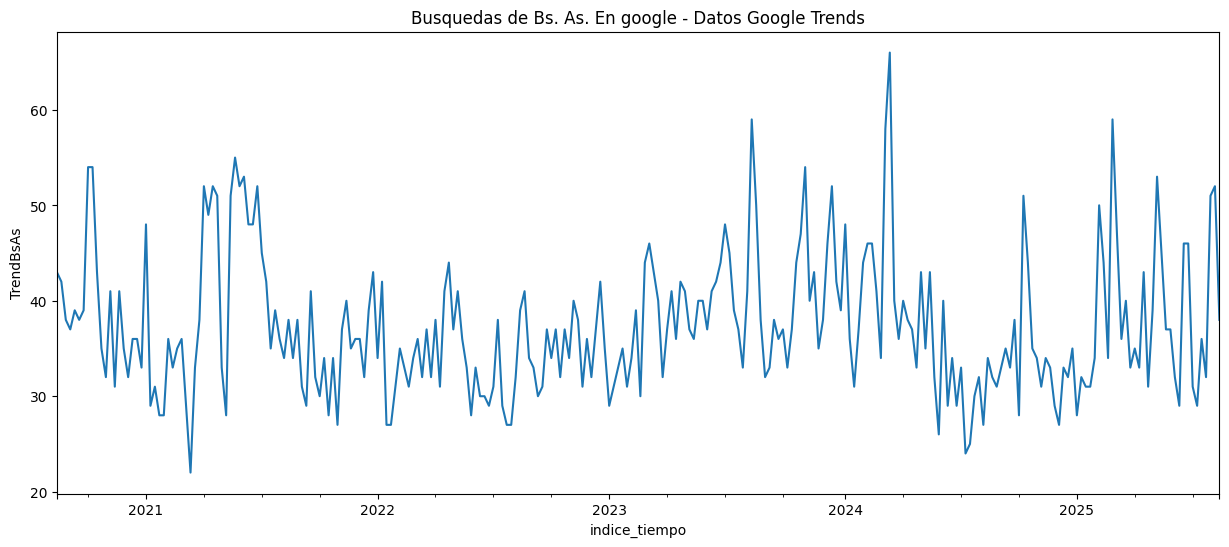

In [ ]:
data2["TrendBsAs"].plot(figsize=(15, 6))
plt.xlabel("indice_tiempo")
plt.ylabel("TrendBsAs")
plt.title("Busquedas de Bs. As. En google - Datos Google Trends")
plt.show()

In [ ]:
'''
Datos del Ejemplo 2.
Se trata de las entradas totales de visitantes a un Parque Nacional con cualquier finalidad principal -ocio, negocios u otro motivo personal- que no sea ser empleado por el Parque.

Fuente = https://datos.yvera.gob.ar/series/api/series/?ids=pn_visitantes_total

'''
url='https://raw.githubusercontent.com/sebcalcagno/AnalisisSeriesTemporales/main/serie-tiempo-parques-nacionales-mensual.csv'
dataoriginal = pd.read_csv(url)

In [ ]:
data=dataoriginal.copy()

In [ ]:
data.head()

,indice_tiempo,no_residentes,residentes,total,buenos_aires_no_residentes,buenos_aires_residentes,buenos_aires_total,cordoba_no_residentes,cordoba_residentes,cordoba_total,...,cuyo_total,litoral_no_residentes,litoral_residentes,litoral_total,norte_no_residentes,norte_residentes,norte_total,patagonia_no_residentes,patagonia_residentes,patagonia_total
0,2008-01-01,198407,352303,550710,0,885,885,145,717,862,...,5144,55335,111408,166743,774,4241,5016,141973,230087,372060
1,2008-02-01,151809,283145,434953,0,624,624,148,475,623,...,4942,53596,85853,139449,1294,5099,6393,96632,186291,282923
2,2008-03-01,148533,173134,321667,0,0,0,147,741,888,...,5900,55130,59150,114280,1696,9204,10900,91382,98317,189699
3,2008-04-01,68558,61539,130097,0,462,462,166,539,705,...,1808,30827,23821,54648,728,3867,4595,36759,31121,67879
4,2008-05-01,43751,48787,92538,0,1091,1091,129,608,737,...,2402,29818,28538,58356,663,5083,5746,13038,11169,24206


In [ ]:
data.fecha = pd.to_datetime(data.indice_tiempo, dayfirst = True)
data.set_index("indice_tiempo", inplace=True)
data.drop(["2020-03-01","2020-04-01","2020-05-01","2020-06-01","2020-07-01","2020-08-01","2020-09-01","2020-10-01","2020-11-01","2020-12-01","2021-01-01","2021-02-01","2021-03-01","2021-04-01","2021-05-01","2021-06-01","2021-07-01","2021-08-01","2021-09-01","2021-10-01","2021-11-01","2021-12-01"],axis=0, inplace=True)

/tmp/ipykernel_263/4188647148.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  data.fecha = pd.to_datetime(data.indice_tiempo, dayfirst = True)


In [ ]:
dataoriginal.drop([146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167],axis=0, inplace=True)
# dataoriginal.drop(range(146, 168), axis=0, inplace=True) ---> Otra forma de hacerlo

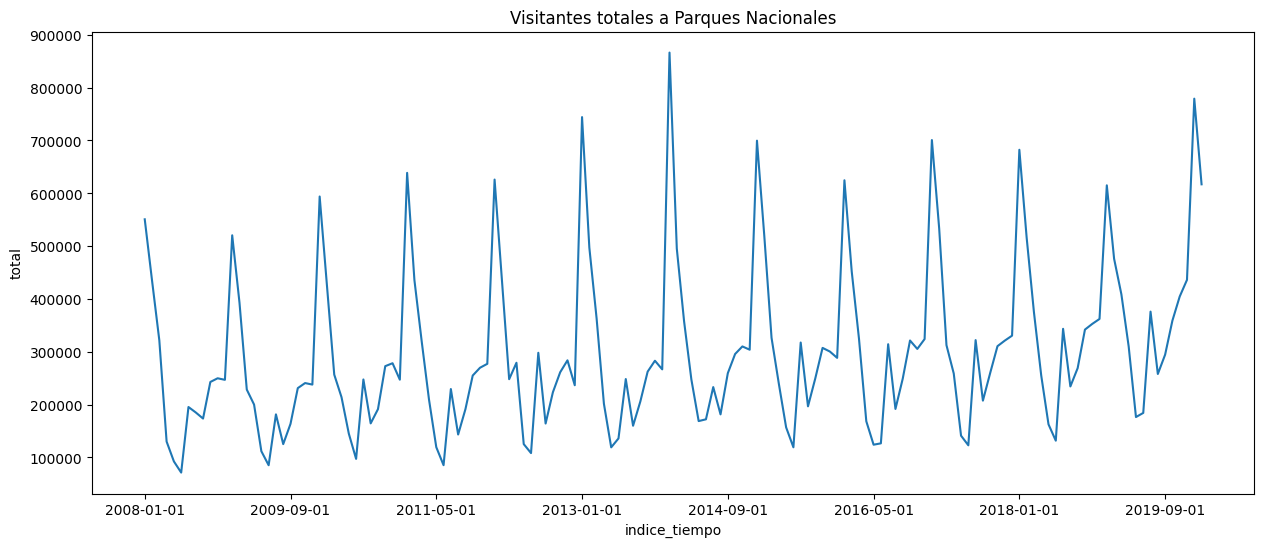

In [ ]:
data["total"].plot(figsize=(15, 6))
plt.xlabel("indice_tiempo")
plt.ylabel("total")
plt.title("Visitantes totales a Parques Nacionales")
plt.show()

# Dividimos los datos en conjuntos de entrenamiento y prueba - Teniendo en cuenta las caracteristicas particulares de ambas series de tiempo ( Aqui continuamos trabjando con ambos casos )

In [ ]:
#Divido la serie de tiempo en entrenamiento y testeo ( manteniendo la cronologia )
train_len = len(data)-12 # Base de entrenamiento, total general menos los ultimos 12 periodos
train = data[0:train_len] # Primeros 134 meses para entrenamiento
test = data[train_len:] # Ultimos 12 meses para testeo

In [ ]:
#Divido la serie de tiempo en entrenamiento y testeo ( manteniendo la cronologia )
train_len2 = len(data2)-7
train2 = data2[0:train_len2]
test2 = data2[train_len2:]

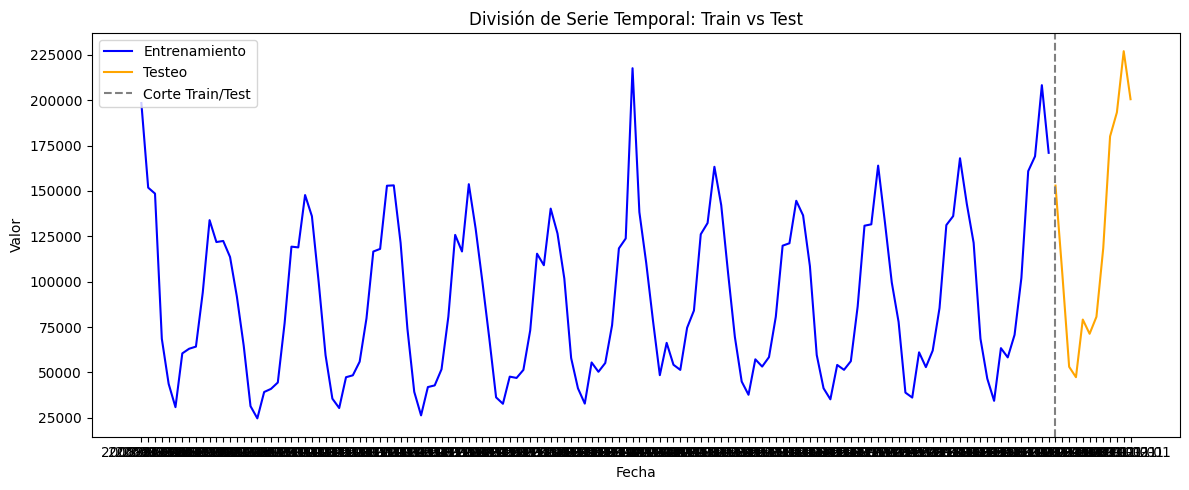

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(train.iloc[:, 0], label='Entrenamiento', color='blue')
plt.plot(test.iloc[:, 0], label='Testeo', color='orange')
plt.axvline(test.index[0], color='gray', linestyle='--', label='Corte Train/Test')

plt.title('División de Serie Temporal: Train vs Test')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()
plt.tight_layout()
plt.show()

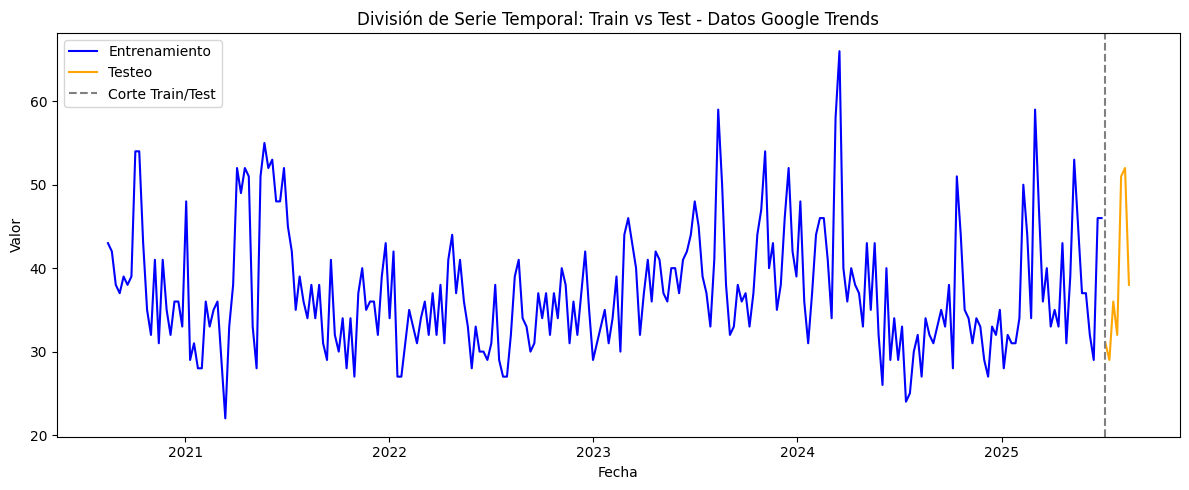

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(train2.iloc[:, 0], label='Entrenamiento', color='blue')
plt.plot(test2.iloc[:, 0], label='Testeo', color='orange')
plt.axvline(test2.index[0], color='gray', linestyle='--', label='Corte Train/Test')

plt.title('División de Serie Temporal: Train vs Test - Datos Google Trends')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()
plt.tight_layout()
plt.show()

# CASO 1 - TRABAJAMOS CON LOS DATOS DE GOOGLE TRENDS

## 1 - Average Method (Los pronósticos de todos los valores futuros son iguales al promedio de los datos históricos)

In [ ]:
numerado2 = train2['TrendBsAs'].sum()
denominador2 = len(train2)
resultado2 = numerado2 / denominador2

In [ ]:
# predicion
test2['prediccion_Average_M2'] = resultado2

/tmp/ipykernel_263/271921665.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test2['prediccion_Average_M2'] = resultado2


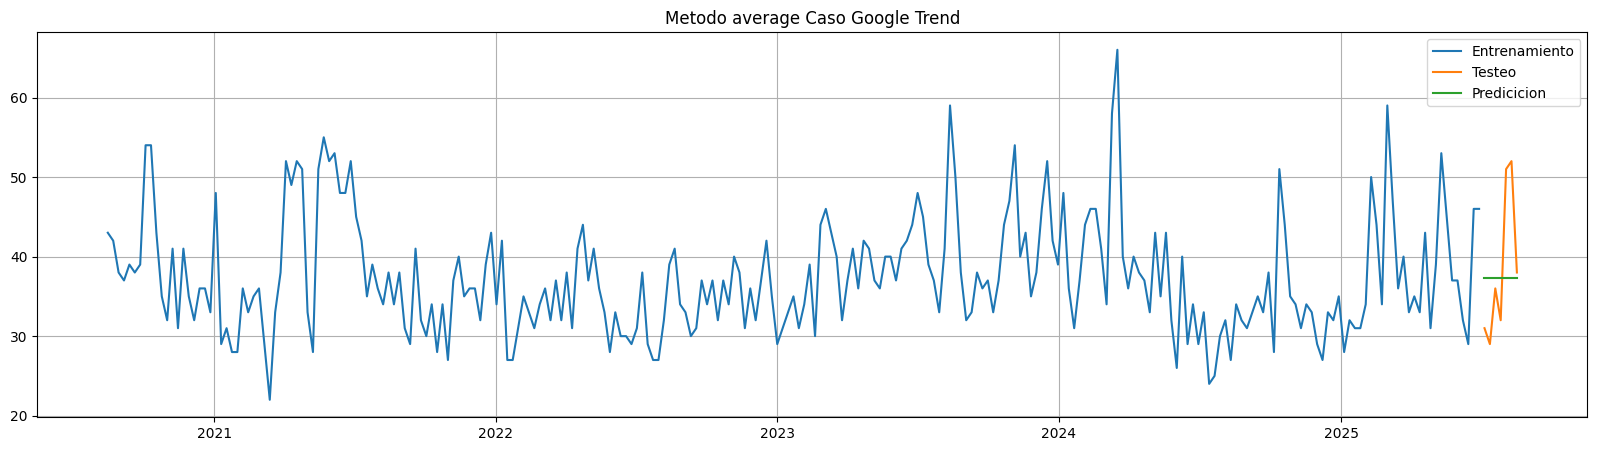

In [ ]:
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train2['TrendBsAs'], label='Entrenamiento')
plt.plot(test2['TrendBsAs'], label='Testeo')
plt.plot(test2['prediccion_Average_M2'], label='Predicicion')
plt.legend(loc='best')
plt.title('Metodo average Caso Google Trend')
plt.show()

In [ ]:
# metricas del pronostico a analizar posteriormente
MAE_AV_METHOD2 = mean_absolute_error(test2['TrendBsAs'], test2['prediccion_Average_M2'])
RMSE_AV_METHOD2 = math.sqrt(MAE_AV_METHOD2)
MAPE_AV_METHOD2 = mean_absolute_percentage_error(test2['TrendBsAs'], test2['prediccion_Average_M2'])

## 2 Metodo Naive (Configuramos todos los pronósticos para que sean el valor del último observación)

In [ ]:
test2['prediccion_Naive_M2'] = train2['TrendBsAs'][train_len2-1]

/tmp/ipykernel_263/3497066946.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test2['prediccion_Naive_M2'] = train2['TrendBsAs'][train_len2-1]
/tmp/ipykernel_263/3497066946.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test2['prediccion_Naive_M2'] = train2['TrendBsAs'][train_len2-1]


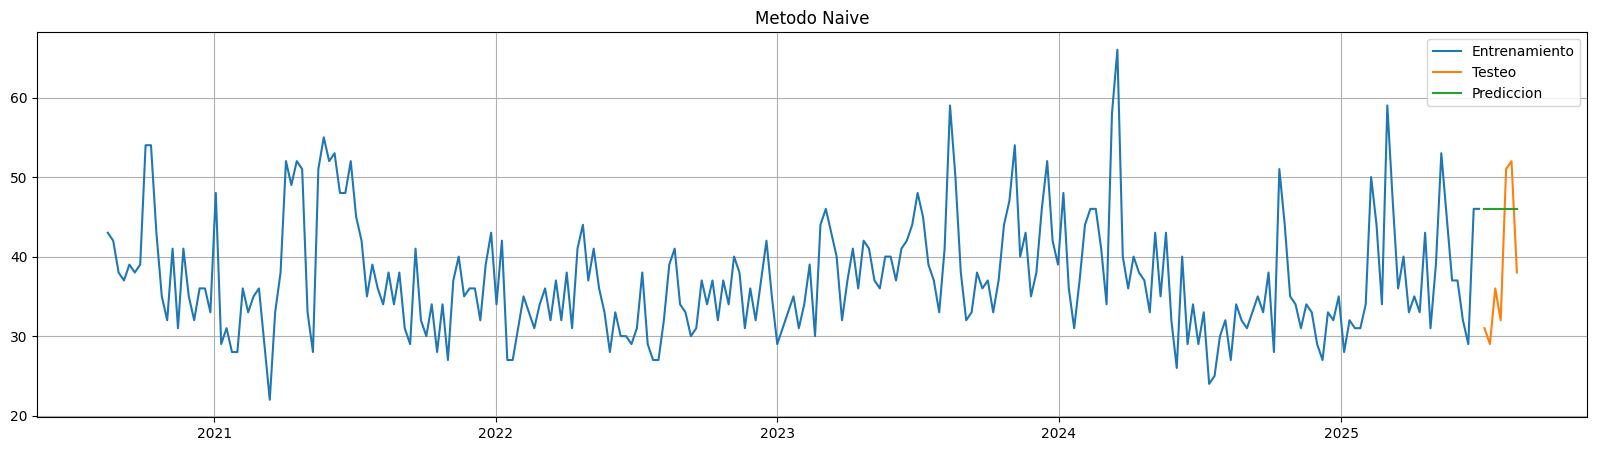

In [ ]:
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train2['TrendBsAs'], label='Entrenamiento')
plt.plot(test2['TrendBsAs'], label='Testeo')
plt.plot(test2['prediccion_Naive_M2'], label='Prediccion')
plt.legend(loc='best')
plt.title('Metodo Naive')
plt.show()

In [ ]:
# metricas del pronostico a analizar posteriormente
MAE_NAIVE_METHOD2 = mean_absolute_error(test2['TrendBsAs'], test2['prediccion_Naive_M2'])
RMSE_NAIVE_METHOD2 = math.sqrt(MAE_NAIVE_METHOD2)
MAPE_NAIVE_METHOD2 = mean_absolute_percentage_error(test2['TrendBsAs'], test2['prediccion_Naive_M2'])

## 3- Seasonal Naïve Method (establecemos cada pronóstico para ser igual al último valor observado de la misma estación del año)

In [ ]:
# Metodo Naive Estacional
seasonal_period2 = 7   # cada 7 observaciones la serie sigue un patron parecido.
naive_forecast2 = train2['TrendBsAs'].iloc[-seasonal_period2:].values

# Repetir el pronóstico para el período de prueba
forecast2 = np.tile(naive_forecast2, int(np.ceil(len(test2) / seasonal_period2)))[:len(test2)]

In [ ]:
# Sumo el pronostico al dataframe
test2['prediccion_Naive_Estacional2'] = forecast2

/tmp/ipykernel_263/2183992748.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test2['prediccion_Naive_Estacional2'] = forecast2


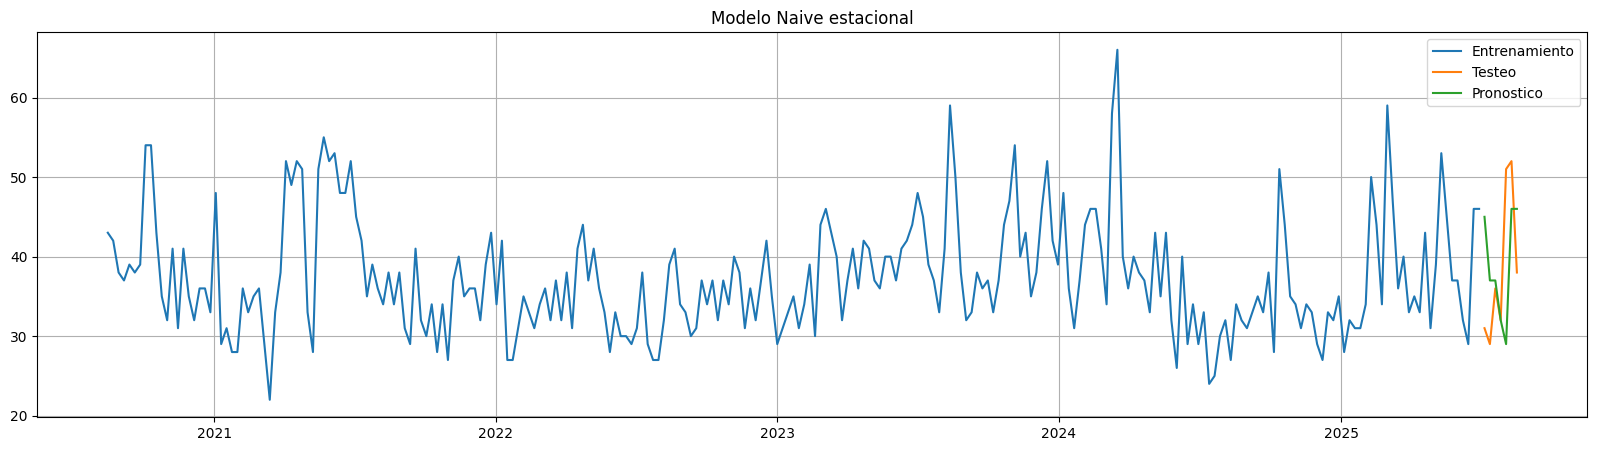

In [ ]:
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train2['TrendBsAs'], label='Entrenamiento')
plt.plot(test2['TrendBsAs'], label='Testeo')
plt.plot(test2['prediccion_Naive_Estacional2'], label='Pronostico')
plt.legend(loc='best')
plt.title('Modelo Naive estacional')
plt.show()

In [ ]:
# metricas del pronostico a analizar posteriormente
MAE_NAIVE_ESTACIONAL_METHOD2 = mean_absolute_error(test2['TrendBsAs'], test2['prediccion_Naive_Estacional2'])
RMSE_NAIVE_ESTACIONAL_METHOD2 = math.sqrt(MAE_NAIVE_ESTACIONAL_METHOD2)
MAPE_NAIVE_ESTACIONAL_METHOD2 = mean_absolute_percentage_error(test2['TrendBsAs'], test2['prediccion_Naive_Estacional2'])

# 4 - Metodo Drift ( calcula los pronósticos futuros extrapolando una línea recta desde la primera observación hasta la última)

Este metodo proyecta hacia el futuro asumiendo que la tendencia pasada continuara. Es una recta que conecta el inicio y el final del entrenamiento y la extiende

In [ ]:
#Divido la serie de tiempo en training y test
train_len2 = len(train2)
train2 = data2[0:train_len2]
trainoriginal2= dataoriginal_Google_trends[0:train_len2]  # adaptacion para poder correr el metodo drift
test2 = data2[train_len2:]
testoriginal2 = dataoriginal_Google_trends[train_len2:] # adaptacion para poder correr el metodo drift

In [ ]:
y_t2 = trainoriginal2.iloc[len(trainoriginal2)-1]['TrendBsAs']
m2 = (y_t2 - trainoriginal2.iloc[0]['TrendBsAs']) / len(trainoriginal2)
y_hat_drift2 = testoriginal2.copy().drop('TrendBsAs', axis=1)
h2 = np.linspace(0,len(y_hat_drift2)-1, len(y_hat_drift2))
y_hat_drift2['drift_forecast2'] = y_t2 + m2 * h2

In [ ]:
print(f"La pendiente de la recta es {m2}")

La pendiente de la recta es 0.011764705882352941


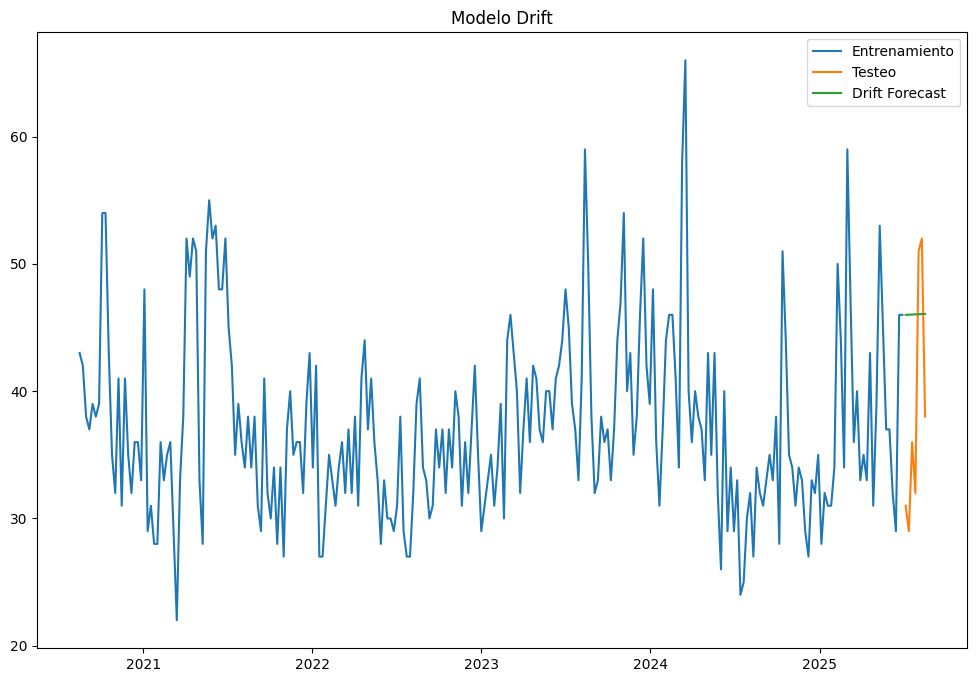

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(trainoriginal2['TrendBsAs'], label='Entrenamiento')
plt.plot(testoriginal2['TrendBsAs'], label='Testeo')
plt.plot(y_hat_drift2['drift_forecast2'],
        label='Drift Forecast')
plt.legend(loc='best')
plt.title('Modelo Drift')
plt.show()


In [ ]:
# metricas del pronostico a analizar posteriormente
MAE_DRIFT_METHOD2 = mean_absolute_error(test2['TrendBsAs'], y_hat_drift2['drift_forecast2'])
RMSE_DRIFT_METHOD2 = math.sqrt(MAE_DRIFT_METHOD2)
MAPE_DRIFT_METHOD2 = mean_absolute_percentage_error(test2['TrendBsAs'], y_hat_drift2['drift_forecast2'])

## Evaluación de la Performance del Pronóstico



- MAE (Error absoluto medio) calcula el promedio de las diferencias absolutas entre los valores predichos y los valores reales. Es una medida directa de cuán lejos, en promedio, están las predicciones del modelo de los resultados reales. Un MAE menor indica un modelo con mejores predicciones.
- RMSE (Error cuadrático medio) es una métrica que cuantifica la diferencia entre los valores predichos y los valores reales en un modelo de predicción. Se calcula como la raíz cuadrada de la media de los cuadrados de los errores. El RMSE es útil porque penaliza los errores grandes más severamente que el MAE, proporcionando una medida más sensible para las variaciones en los errores. Un RMSE más bajo indica un modelo que se ajusta mejor a los datos observados.
-MAPE (Error porcentual absoluto medio) es una métrica que calcula el error porcentual promedio entre los valores predichos y los valores reales. Es especialmente útil para evaluar la precisión relativa de un modelo en términos porcentuales, siendo menos sensible a valores atípicos que el RMSE.

In [ ]:
# Average Method

resultados_AV_METHOD2 = pd.DataFrame({'Metodo':['Average Method'],'MAE':[MAE_AV_METHOD2] ,'RMSE': [RMSE_AV_METHOD2], 'MAPE': [MAPE_AV_METHOD2 * 100]})
resultados_AV_METHOD2 = resultados_AV_METHOD2[['Metodo', 'MAE','RMSE', 'MAPE']]

# Naïve Method

resultados_NAIVE_METHOD2 = pd.DataFrame({'Metodo':['Naïve Method'],'MAE':[MAE_NAIVE_METHOD2] ,'RMSE': [RMSE_NAIVE_METHOD2], 'MAPE': [MAPE_NAIVE_METHOD2 * 100]})
resultados_NAIVE_METHOD2 = resultados_NAIVE_METHOD2[['Metodo', 'MAE','RMSE', 'MAPE']]

# Naive estacional

resultados_NAIVE_ESTACIONAL_METHOD2 = pd.DataFrame({'Metodo':['Seasonal Naïve Method'],'MAE':[MAE_NAIVE_ESTACIONAL_METHOD2] ,'RMSE': [RMSE_NAIVE_ESTACIONAL_METHOD2], 'MAPE': [MAPE_NAIVE_ESTACIONAL_METHOD2 * 100]})
resultados_NAIVE_ESTACIONAL_METHOD2 = resultados_NAIVE_ESTACIONAL_METHOD2[['Metodo', 'MAE','RMSE', 'MAPE']]

# Metodo Drift

resultados_DRIFT_METHOD2 = pd.DataFrame({'Metodo':['Drift Method'],'MAE':[MAE_DRIFT_METHOD2] ,'RMSE': [RMSE_DRIFT_METHOD2], 'MAPE': [MAPE_DRIFT_METHOD2 * 100]})

In [ ]:
resultados2 = pd.concat([resultados_AV_METHOD2, resultados_NAIVE_METHOD2, resultados_NAIVE_ESTACIONAL_METHOD2, resultados_DRIFT_METHOD2], ignore_index=True)

print(resultados2)

                  Metodo        MAE      RMSE       MAPE
0         Average Method   7.183193  2.680148  17.997714
1           Naïve Method  10.714286  3.273268  31.561511
2  Seasonal Naïve Method   8.428571  2.903200  21.607660
3           Drift Method  10.719328  3.274038  31.589595


El mejor modelo no siempre es el mas complejo. Aca el metodo estacional naive  supera a todos porque capta correctamente la estacionalidad de la serie. Este resultado refuerza la importancia de entender la etructura de la serie ante de elegir el modelo

Graficos de las metricas

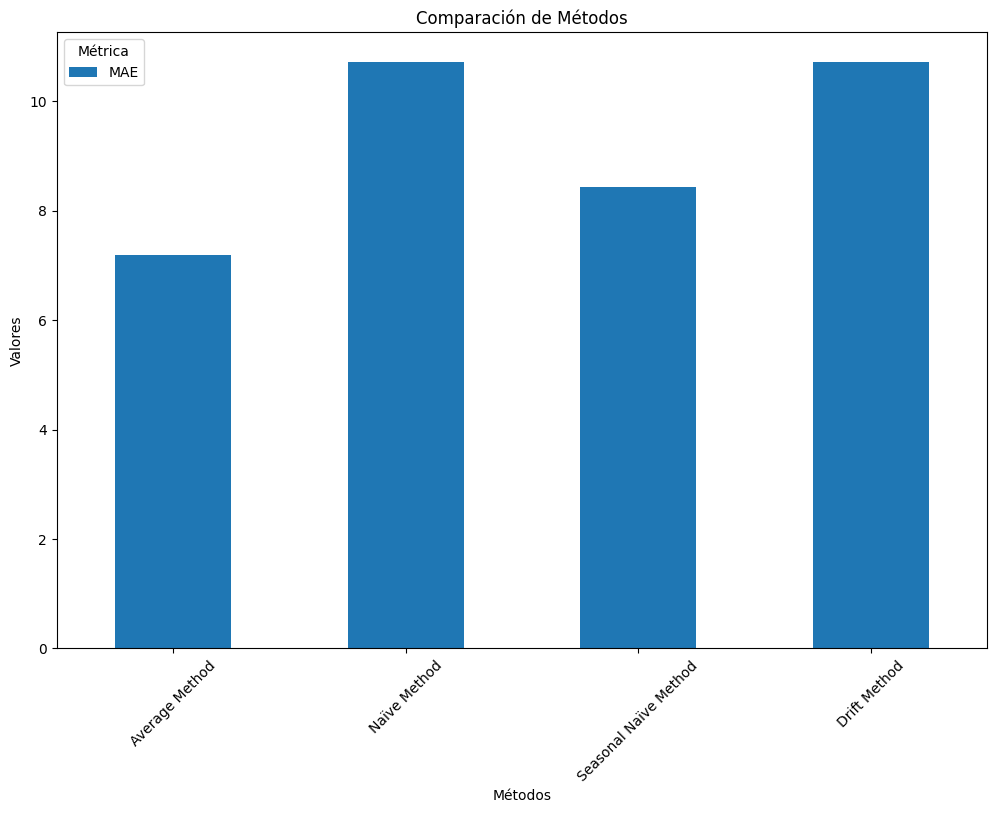

In [ ]:
columnas_a_mostrar2 = ['Metodo', 'MAE']
resultados_mostrar2 = resultados2[columnas_a_mostrar2]

resultados_mostrar2.plot(kind='bar', x='Metodo', figsize=(12, 8))

plt.xlabel('Métodos')
plt.ylabel('Valores')
plt.title('Comparación de Métodos')
plt.xticks(rotation=45)
plt.legend(title='Métrica')
plt.show()

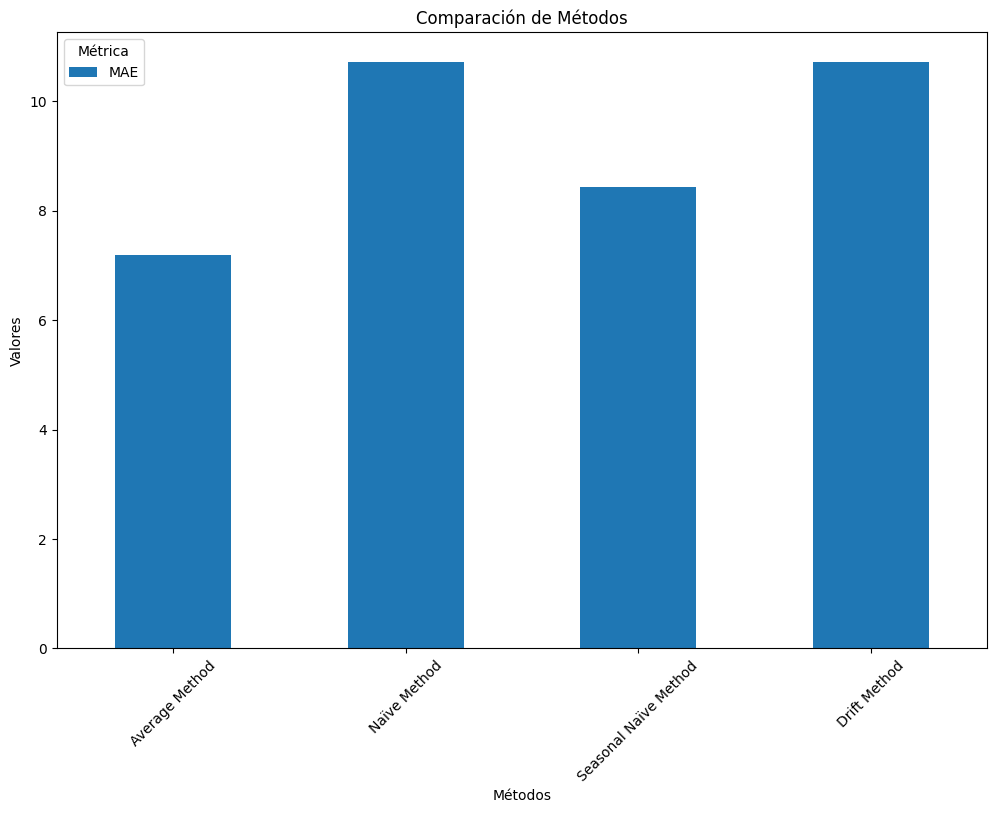

In [ ]:
columnas_a_mostrar2 = ['Metodo', 'MAE']
resultados_mostrar2 = resultados2[columnas_a_mostrar2]

resultados_mostrar2.plot(kind='bar', x='Metodo', figsize=(12, 8))

plt.xlabel('Métodos')
plt.ylabel('Valores')
plt.title('Comparación de Métodos')
plt.xticks(rotation=45)
plt.legend(title='Métrica')
plt.show()

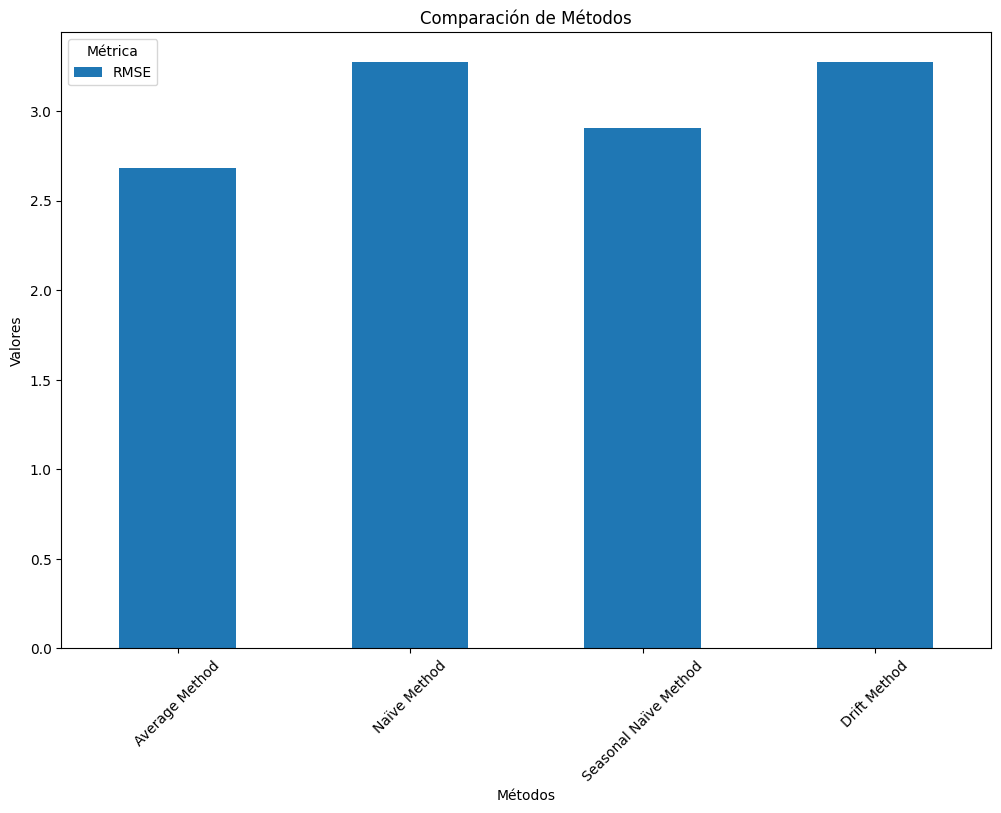

In [ ]:
columnas_a_mostrar2 = ['Metodo', 'RMSE']
resultados_mostrar2 = resultados2[columnas_a_mostrar2]

resultados_mostrar2.plot(kind='bar', x='Metodo', figsize=(12, 8))

plt.xlabel('Métodos')
plt.ylabel('Valores')
plt.title('Comparación de Métodos')
plt.xticks(rotation=45)
plt.legend(title='Métrica')
plt.show()

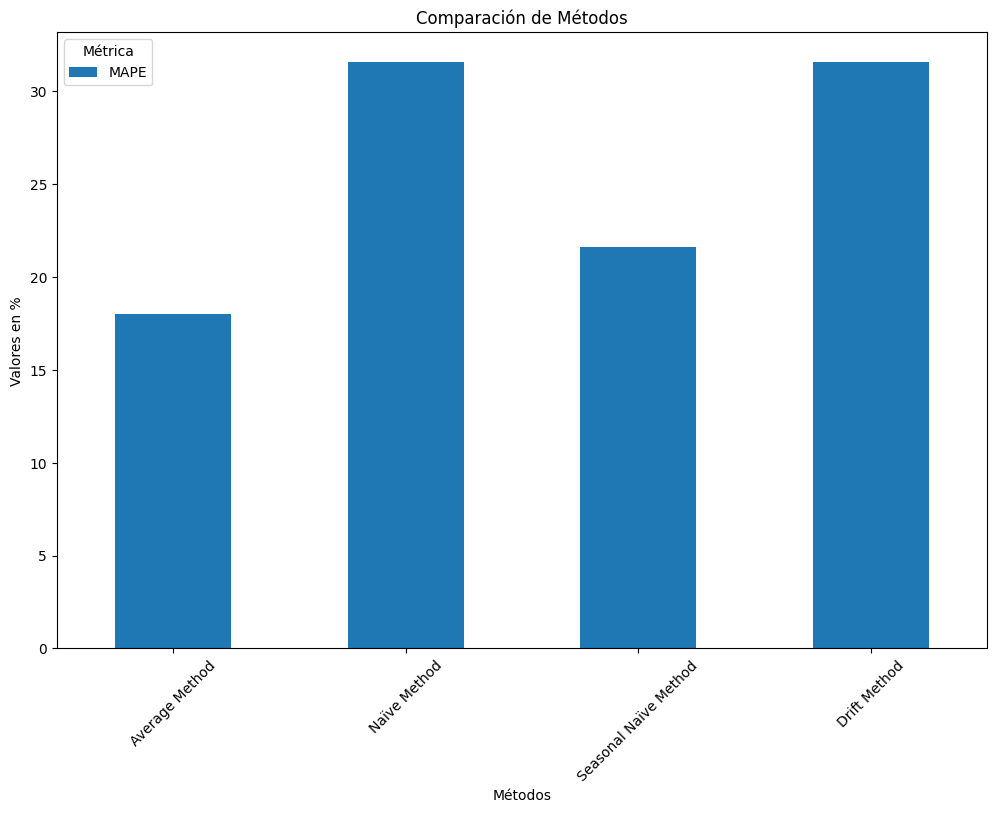

In [ ]:
columnas_a_mostrar2 = ['Metodo', 'MAPE']
resultados_mostrar2 = resultados2[columnas_a_mostrar2]

resultados_mostrar2.plot(kind='bar', x='Metodo', figsize=(12, 8))

plt.xlabel('Métodos')
plt.ylabel('Valores en %')
plt.title('Comparación de Métodos')
plt.xticks(rotation=45)
plt.legend(title='Métrica')
plt.show()

## Otro Método Simple de Forecasting



- Holt winters exponential smoothing = El método de suavizado exponencial de Holt-Winters permite pronosticar valores futuros basándose en la observación de datos pasados. Se adapta a datos con tendencias y estacionalidades utilizando tres componentes: nivel (media), tendencia (cambio en el nivel) y estacionalidad (variación repetitiva a lo largo del tiempo). Pondera las observaciones recientes con más peso que las antiguas. Este es un modelo muy usado cuando la serie tiene patrones que crecen o decrecen en proporcion al nivel de la serie

La estacionalidad no es constante: los ciclos son mas grandes cuando la serie tiene valores mas altos. Esto indica que los efectos estacionales son proporcionales al nivel de la serie (relación multiplicativa).

Usar un modelo aditivo, que suma una estacionalidad constante, subestimaria los picos y valles en niveles altos.

In [ ]:
len(data2)

262

In [ ]:
len(train2)

255

In [ ]:
#Divido la serie de tiempo en entrenamiento y testeo
train_len2 = len(train2)
train2 = data2[0:train_len2]
test2 = data2[train_len2:]

In [ ]:
# Tendencia mULTIPLICATIVA + estacionalidad mULTIPLICATIVA
fitted_model_MM = ExponentialSmoothing(train2["TrendBsAs"],trend="mul",seasonal="mul",seasonal_periods=7).fit()
test_predictions_MM = fitted_model_MM.forecast(7)

# Tendencia aditiva + estacionalidad aditiva
fitted_model_AA = ExponentialSmoothing(train2["TrendBsAs"], trend="add", seasonal="add", seasonal_periods=7).fit()
test_predictions_AA = fitted_model_AA.forecast(7)

# Tendencia aditiva + estacionalidad multiplicativa
fitted_model_AM = ExponentialSmoothing(train2["TrendBsAs"], trend="add", seasonal="mul", seasonal_periods=7).fit()
test_predictions_AM = fitted_model_AM.forecast(7)

# Tendencia multiplicativa + estacionalidad aditiva
fitted_model_MA = ExponentialSmoothing(train2["TrendBsAs"], trend="mul", seasonal="add", seasonal_periods=7).fit()
test_predictions_MA = fitted_model_MA.forecast(7)

# Solo estacionalidad aditiva (sin tendencia)
fitted_model_AN = ExponentialSmoothing(train2["TrendBsAs"], trend=None, seasonal="add", seasonal_periods=7).fit()
test_predictions_AN = fitted_model_AN.forecast(7)

# Sin tendencia ni estacionalidad (modelo simple)
fitted_model_NN = ExponentialSmoothing(train2["TrendBsAs"], trend=None, seasonal=None).fit()
test_predictions_NN = fitted_model_NN.forecast(7)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  

In [ ]:
# Tendencia mULTIPLICATIVA + estacionalidad mULTIPLICATIVA
prediccion_MM=[]

for dia in range(0,7):
  prediccion_MM.append(test_predictions_MM[dia])

# Tendencia aditiva + estacionalidad aditiva

prediccion_AA=[]

for dia in range(0,7):
  prediccion_AA.append(test_predictions_AA[dia])

# Tendencia aditiva + estacionalidad multiplicativa

prediccion_AM=[]

for dia in range(0,7):
  prediccion_AM.append(test_predictions_AM[dia])

# Tendencia multiplicativa + estacionalidad aditiva

prediccion_MA=[]

for dia in range(0,7):
  prediccion_MA.append(test_predictions_MA[dia])

# Solo estacionalidad aditiva (sin tendencia)

prediccion_AN=[]

for dia in range(0,7):
  prediccion_AN.append(test_predictions_AN[dia])

# Sin tendencia ni estacionalidad (modelo simple)


prediccion_NN=[]

for dia in range(0,7):
  prediccion_NN.append(test_predictions_NN[dia])

/tmp/ipykernel_263/1128811956.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  prediccion_MM.append(test_predictions_MM[dia])
/tmp/ipykernel_263/1128811956.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  prediccion_AA.append(test_predictions_AA[dia])
/tmp/ipykernel_263/1128811956.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  prediccion_AM.append(test_predictions_AM[dia])
/tmp/ipykernel_263/1128811956.py:26: FutureWarn

In [ ]:
# Tendencia mULTIPLICATIVA + estacionalidad mULTIPLICATIVA
print(prediccion_MM)

# Tendencia aditiva + estacionalidad aditiva
print(prediccion_AA)

# Tendencia aditiva + estacionalidad multiplicativa
print(prediccion_AM)

# Tendencia multiplicativa + estacionalidad aditiva
print(prediccion_MA)

# Solo estacionalidad aditiva (sin tendencia)
print(prediccion_AN)

# Sin tendencia ni estacionalidad (modelo simple)
print(prediccion_NN)

[np.float64(39.597435199992596), np.float64(39.70398922979079), np.float64(40.5862113866759), np.float64(40.63424792926735), np.float64(41.7115486524283), np.float64(40.81755761258358), np.float64(39.525426210619926)]
[np.float64(39.7882327538454), np.float64(40.177339576514534), np.float64(40.677268957279985), np.float64(41.03875270597342), np.float64(41.90106454911423), np.float64(41.17007820602225), np.float64(39.90078716377004)]
[np.float64(39.78194054724543), np.float64(39.95489338089238), np.float64(40.89750309202606), np.float64(41.009583361605166), np.float64(42.154287695702635), np.float64(41.317949613742535), np.float64(40.080685024310405)]
[np.float64(39.61039314254541), np.float64(39.937185745040196), np.float64(40.37616993962221), np.float64(40.6760496400359), np.float64(41.4706691706145), np.float64(40.681222861413445), np.float64(39.35186597893883)]
[np.float64(39.789744166023056), np.float64(40.17867582551933), np.float64(40.67868793435693), np.float64(41.04040226722731

In [ ]:
# Tendencia mULTIPLICATIVA + estacionalidad mULTIPLICATIVA
test2['prediccion_MM'] = np.array(prediccion_MM)

# Tendencia aditiva + estacionalidad aditiva
test2['prediccion_AA'] = np.array(prediccion_AA)


# Tendencia aditiva + estacionalidad multiplicativa
test2['prediccion_AM'] = np.array(prediccion_AM)


# Tendencia multiplicativa + estacionalidad aditiva
test2['prediccion_MA'] = np.array(prediccion_MA)


# Solo estacionalidad aditiva (sin tendencia)
test2['prediccion_AN'] = np.array(prediccion_AN)


# Sin tendencia ni estacionalidad (modelo simple)
test2['prediccion_NN'] = np.array(prediccion_NN)


/tmp/ipykernel_263/3925468318.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test2['prediccion_MM'] = np.array(prediccion_MM)
/tmp/ipykernel_263/3925468318.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test2['prediccion_AA'] = np.array(prediccion_AA)
/tmp/ipykernel_263/3925468318.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/p

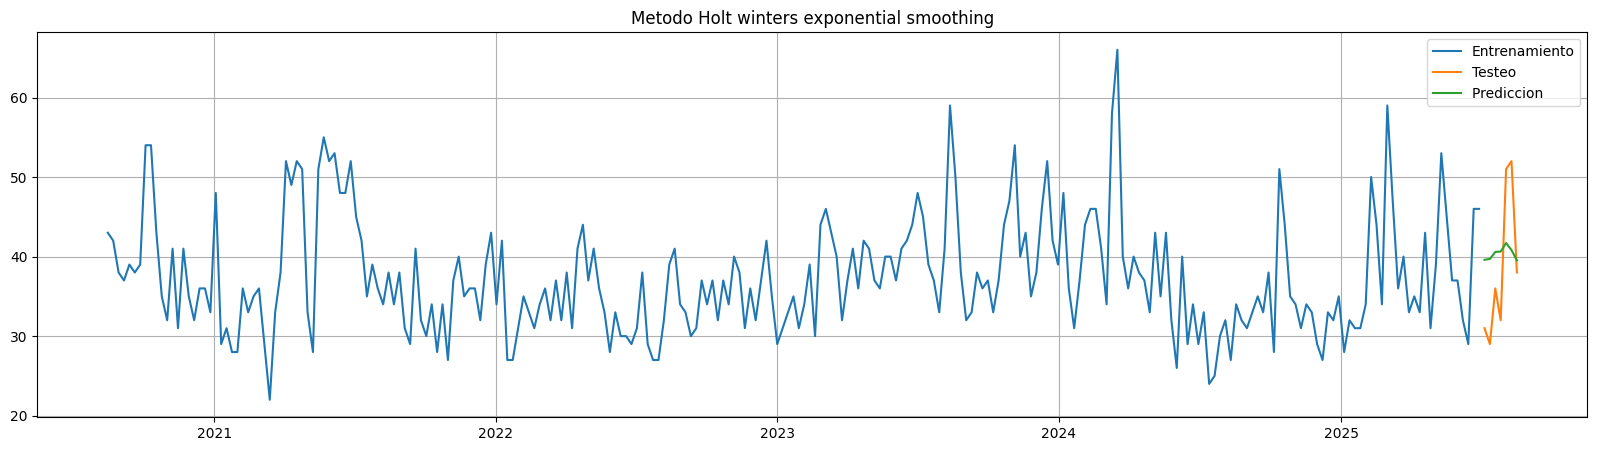

In [ ]:
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train2['TrendBsAs'], label='Entrenamiento')
plt.plot(test2['TrendBsAs'], label='Testeo')
plt.plot(test2['prediccion_MM'], label='Prediccion ')
plt.legend(loc='best')
plt.title('Metodo Holt winters exponential smoothing')
plt.show()

In [ ]:
# Tendencia mULTIPLICATIVA + estacionalidad mULTIPLICATIVA
MAE_Holt_winters_METHOD2_MM = mean_absolute_error(test2['TrendBsAs'], test2['prediccion_MM'])
RMSE_Holt_winters_METHOD2_MM = math.sqrt(MAE_Holt_winters_METHOD2_MM)
MAPE_Holt_winters_METHOD2_MM = mean_absolute_percentage_error(test2['TrendBsAs'], test2['prediccion_MM'])

# Tendencia aditiva + estacionalidad aditiva
MAE_Holt_winters_METHOD2_AA = mean_absolute_error(test2['TrendBsAs'], test2['prediccion_AA'])
RMSE_Holt_winters_METHOD2_AA = math.sqrt(MAE_Holt_winters_METHOD2_AA)
MAPE_Holt_winters_METHOD2_AA = mean_absolute_percentage_error(test2['TrendBsAs'], test2['prediccion_AA'])


# Tendencia aditiva + estacionalidad multiplicativa
MAE_Holt_winters_METHOD2_AM = mean_absolute_error(test2['TrendBsAs'], test2['prediccion_AM'])
RMSE_Holt_winters_METHOD2_AM = math.sqrt(MAE_Holt_winters_METHOD2_AM)
MAPE_Holt_winters_METHOD2_AM = mean_absolute_percentage_error(test2['TrendBsAs'], test2['prediccion_AM'])


# Tendencia multiplicativa + estacionalidad aditiva
MAE_Holt_winters_METHOD2_MA = mean_absolute_error(test2['TrendBsAs'], test2['prediccion_MA'])
RMSE_Holt_winters_METHOD2_MA = math.sqrt(MAE_Holt_winters_METHOD2_MA)
MAPE_Holt_winters_METHOD2_MA = mean_absolute_percentage_error(test2['TrendBsAs'], test2['prediccion_MA'])


# Solo estacionalidad aditiva (sin tendencia)
MAE_Holt_winters_METHOD2_AN = mean_absolute_error(test2['TrendBsAs'], test2['prediccion_AN'])
RMSE_Holt_winters_METHOD2_AN = math.sqrt(MAE_Holt_winters_METHOD2_AN)
MAPE_Holt_winters_METHOD2_AN = mean_absolute_percentage_error(test2['TrendBsAs'], test2['prediccion_AN'])


# Sin tendencia ni estacionalidad (modelo simple)
MAE_Holt_winters_METHOD2_NN = mean_absolute_error(test2['TrendBsAs'], test2['prediccion_NN'])
RMSE_Holt_winters_METHOD2_NN = math.sqrt(MAE_Holt_winters_METHOD2_NN)
MAPE_Holt_winters_METHOD2_NN = mean_absolute_percentage_error(test2['TrendBsAs'], test2['prediccion_NN'])


In [ ]:

# Tendencia mULTIPLICATIVA + estacionalidad mULTIPLICATIVA
print(f"Metrica MAE con Metodo Tendencia mULTIPLICATIVA + estacionalidad mULTIPLICATIVA : {MAE_Holt_winters_METHOD2_MM}")
print(f"Metrica RMSE con Metodo Tendencia mULTIPLICATIVA + estacionalidad mULTIPLICATIVA : {RMSE_Holt_winters_METHOD2_MM}")
print(f"Metrica MAPE con Metodo Tendencia mULTIPLICATIVA + estacionalidad mULTIPLICATIVA : {MAPE_Holt_winters_METHOD2_MM}")


# Tendencia aditiva + estacionalidad aditiva
print(f"Metrica MAE con Metodo Tendencia aditiva + estacionalidad aditiva : {MAE_Holt_winters_METHOD2_AA}")
print(f"Metrica RMSE con Metodo Tendencia aditiva + estacionalidad aditiva : {RMSE_Holt_winters_METHOD2_AA}")
print(f"Metrica MAPE con Metodo Tendencia aditiva + estacionalidad aditiva : {MAPE_Holt_winters_METHOD2_AA}")


# Tendencia aditiva + estacionalidad multiplicativa
print(f"Metrica MAE con Metodo Tendencia aditiva + estacionalidad multiplicativa : {MAE_Holt_winters_METHOD2_AM}")
print(f"Metrica RMSE con Metodo Tendencia aditiva + estacionalidad multiplicativa : {RMSE_Holt_winters_METHOD2_AM}")
print(f"Metrica MAPE con Metodo Tendencia aditiva + estacionalidad multiplicativa : {MAPE_Holt_winters_METHOD2_AM}")


# Tendencia multiplicativa + estacionalidad aditiva
print(f"Metrica MAE con Metodo Tendencia multiplicativa + estacionalidad aditiva : {MAE_Holt_winters_METHOD2_MA}")
print(f"Metrica RMSE con Metodo Tendencia multiplicativa + estacionalidad aditiva : {RMSE_Holt_winters_METHOD2_MA}")
print(f"Metrica MAPE con Metodo Tendencia multiplicativa + estacionalidad aditiva : {MAPE_Holt_winters_METHOD2_MA}")


# Solo estacionalidad aditiva (sin tendencia)
print(f"Metrica MAE con Metodo Solo estacionalidad aditiva (sin tendencia) : {MAE_Holt_winters_METHOD2_AN}")
print(f"Metrica RMSE con Metodo Solo estacionalidad aditiva (sin tendencia) : {RMSE_Holt_winters_METHOD2_AN}")
print(f"Metrica MAPE con Metodo Solo estacionalidad aditiva (sin tendencia) : {MAPE_Holt_winters_METHOD2_AN}")


# Sin tendencia ni estacionalidad (modelo simple)
print(f"Metrica MAE con Metodo Sin tendencia ni estacionalidad (modelo simple) : {MAE_Holt_winters_METHOD2_NN}")
print(f"Metrica RMSE con Metodo Sin tendencia ni estacionalidad (modelo simple) : {RMSE_Holt_winters_METHOD2_NN}")
print(f"Metrica MAPE con Metodo Sin tendencia ni estacionalidad (modelo simple) : {RMSE_Holt_winters_METHOD2_NN}")


Metrica MAE con Metodo Tendencia mULTIPLICATIVA + estacionalidad mULTIPLICATIVA : 7.788314813047813
Metrica RMSE con Metodo Tendencia mULTIPLICATIVA + estacionalidad mULTIPLICATIVA : 2.7907552406199674
Metrica MAPE con Metodo Tendencia mULTIPLICATIVA + estacionalidad mULTIPLICATIVA : 0.21156728082726292
Metrica MAE con Metodo Tendencia aditiva + estacionalidad aditiva : 7.9301769146067
Metrica RMSE con Metodo Tendencia aditiva + estacionalidad aditiva : 2.8160569799999964
Metrica MAPE con Metodo Tendencia aditiva + estacionalidad aditiva : 0.21685728317698869
Metrica MAE con Metodo Tendencia aditiva + estacionalidad multiplicativa : 7.893195442376324
Metrica RMSE con Metodo Tendencia aditiva + estacionalidad multiplicativa : 2.809483127263149
Metrica MAPE con Metodo Tendencia aditiva + estacionalidad multiplicativa : 0.21603697653933018
Metrica MAE con Metodo Tendencia multiplicativa + estacionalidad aditiva : 7.8285389163078
Metrica RMSE con Metodo Tendencia multiplicativa + estaciona

## Validación Cruzada de Series de Tiempo
- K-fold Cross-Validation en series de tiempo

K-fold Cross-Validation consiste en dividir los datos en K partes ("folds")entrenar el modelo en K-1 partes y validar en la parte restante repitiendo esto K veces con diferentes particiones.


In [ ]:
train_ind2 = int(len(data2)*0.8)
train2 = data2[:train_ind2]
test2 = data2[train_ind2:]

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
from math import sqrt
model2 = ExponentialSmoothing(train2,trend="mul",seasonal='mul', seasonal_periods=7).fit()
pred2 = model2.predict(start=test2.index[0], end=test2.index[-1])
MSE2=round(mean_squared_error(test2, pred2),2)
MSE2

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


172.85

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(gap=2, n_splits=5)

train_sets2 = []
test_sets2 = []

for i, (train_index2, test_index2) in enumerate(tscv.split(data2)):
    train_data2 = data2.iloc[train_index2, 0]
    test_data2 = data2.iloc[test_index2, 0]

    train_sets2.append(train_data2)
    test_sets2.append(test_data2)



train12, test12 = train_sets2[0], test_sets2[0]
train22, test22 = train_sets2[1], test_sets2[1]
train32, test32 = train_sets2[2], test_sets2[2]
train42, test42 = train_sets2[3], test_sets2[3]
train52, test52 = train_sets2[4], test_sets2[4]

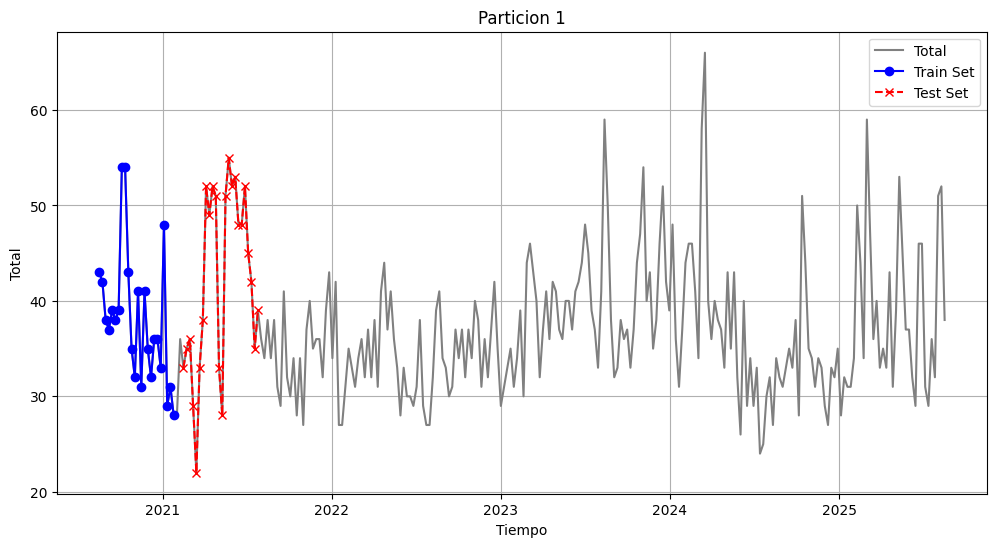

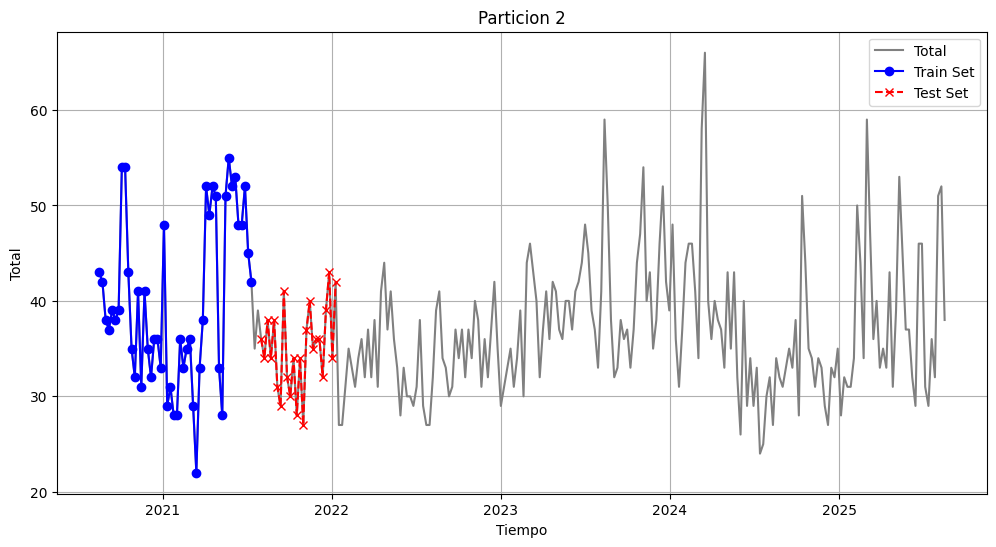

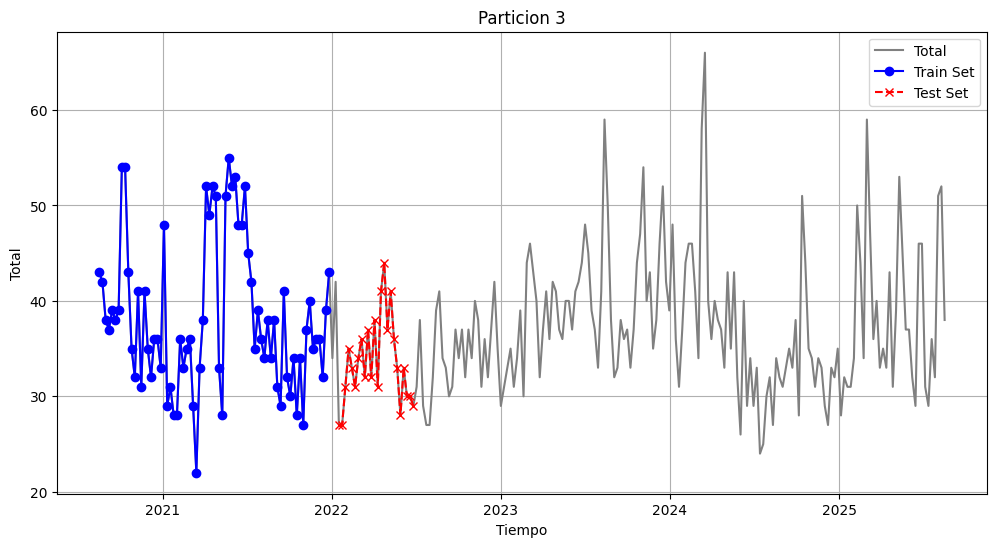

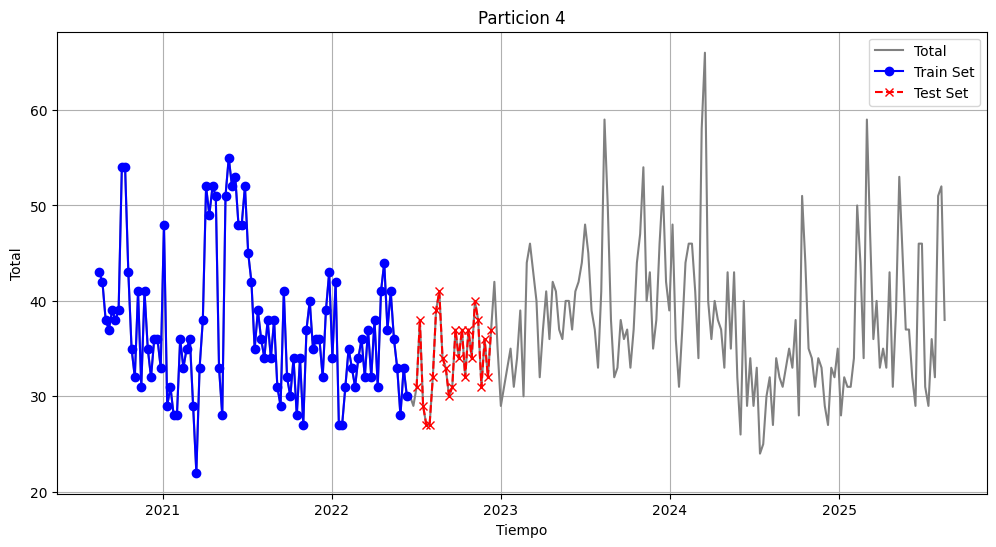

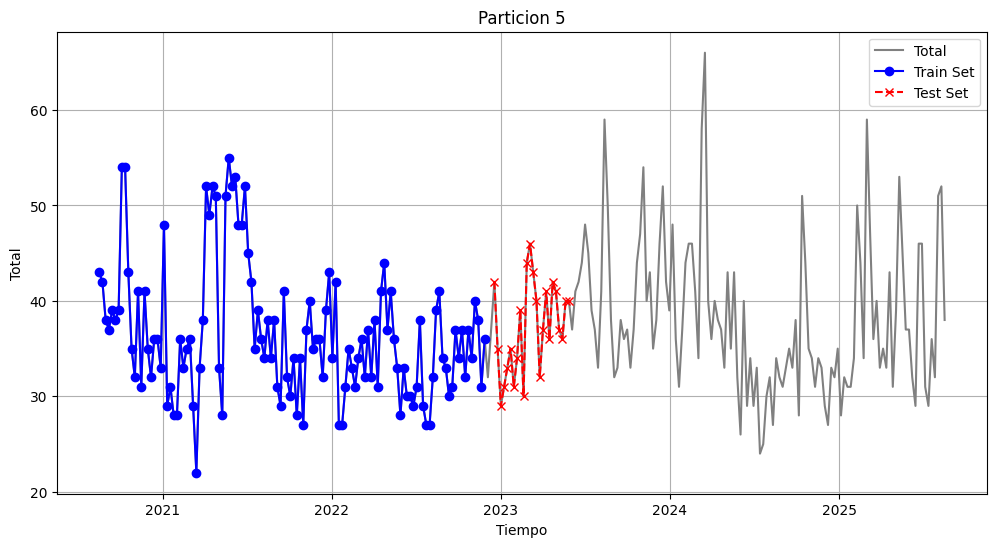

In [ ]:
# Grafico orientativo

tscv = TimeSeriesSplit(gap=2, n_splits=5) #

for i, (train_index2, test_index2) in enumerate(tscv.split(data)):
    plt.figure(figsize=(12, 6))
    plt.plot(data2.index, data2['TrendBsAs'], label='Total', color='grey')

    plt.plot(data2.index[train_index2], data2['TrendBsAs'].iloc[train_index2], 'o-', label='Train Set', color='blue')
    plt.plot(data2.index[test_index2], data2['TrendBsAs'].iloc[test_index2], 'x--', label='Test Set', color='red')

    plt.title(f'Particion {i + 1}')
    plt.xlabel('Tiempo')
    plt.ylabel('Total')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
model12 = ExponentialSmoothing(train12,trend="mul", seasonal='mul', seasonal_periods=7).fit()
pred12 = model12.predict(start=test12.index[0], end=test12.index[-1])
MSE12=round(mean_squared_error(test12, pred12),2)
model22 = ExponentialSmoothing(train22,trend="mul", seasonal='mul', seasonal_periods=7).fit()
pred22 = model2.predict(start=test22.index[0], end=test22.index[-1])
MSE22=round(mean_squared_error(test22, pred22),2)
model32 = ExponentialSmoothing(train32,trend="mul", seasonal='mul', seasonal_periods=7).fit()
pred32 = model32.predict(start=test32.index[0], end=test32.index[-1])
MSE32=round(mean_squared_error(test32, pred32),2)
model42 = ExponentialSmoothing(train42,trend="mul", seasonal='mul', seasonal_periods=7).fit()
pred42 = model42.predict(start=test42.index[0], end=test42.index[-1])
MSE42=round(mean_squared_error(test42, pred42),2)
model52 = ExponentialSmoothing(train52,trend="mul", seasonal='mul', seasonal_periods=7).fit()
pred52 = model52.predict(start=test52.index[0], end=test52.index[-1])
MSE52=round(mean_squared_error(test52, pred52),2)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  

In [ ]:
print ("Error cuadratico medio:", MSE2)
print ("Error cuadratico medio 1:", MSE12)
print ("Error cuadratico medio 2:", MSE22)
print ("Error cuadratico medio 3:", MSE32)
print ("Error cuadratico medio 4:", MSE42)
print ("Error cuadratico medio 5:", MSE52)

Error cuadratico medio: 172.85
Error cuadratico medio 1: 505.19
Error cuadratico medio 2: 20.02
Error cuadratico medio 3: 96.12
Error cuadratico medio 4: 75.32
Error cuadratico medio 5: 114.82


In [ ]:
Overall_MSE2=round((MSE12+MSE22+MSE32+MSE42+MSE52)/5,2)
print ("Error cuadratico medio general:", Overall_MSE2)

Error cuadratico medio general: 162.29


# CASO 2

## 1 - Average Method

In [ ]:
numerado = train['total'].sum()
denominador = len(train)
resultado = numerado / denominador

In [ ]:
# predicion
test['prediccion_Average_M'] = resultado

In [ ]:
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train['total'], label='Entrenamiento')
plt.plot(test['total'], label='Testeo')
plt.plot(test['prediccion_Average_M'], label='Predicicion')
plt.legend(loc='best')
plt.title('Metodo average')
plt.show()

In [ ]:
# metricas del pronostico a analizar posteriormente
MAE_AV_METHOD = mean_absolute_error(test['total'], test['prediccion_Average_M'])
RMSE_AV_METHOD = math.sqrt(MAE_AV_METHOD)
MAPE_AV_METHOD = mean_absolute_percentage_error(test['total'], test['prediccion_Average_M'])

## 2 - Metodo Naive

In [ ]:
test['prediccion_Naive_M'] = train['total'][train_len-1]

In [ ]:
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train['total'], label='Entrenamiento')
plt.plot(test['total'], label='Testeo')
plt.plot(test['prediccion_Naive_M'], label='Prediccion')
plt.legend(loc='best')
plt.title('Metodo Naive')
plt.show()

In [ ]:
MAE_NAIVE_METHOD = mean_absolute_error(test['Total'], test['prediccion_Naive_M'])
RMSE_NAIVE_METHOD = math.sqrt(MAE_NAIVE_METHOD)
MAPE_NAIVE_METHOD = mean_absolute_percentage_error(test2['Total'], test['prediccion_Naive_M'])


## 3 - Metodo Seasonal Naive

In [ ]:
seasonal_period = 12  # Mensual
naive_forecast = train['total'].iloc[-seasonal_period:].values  # Últimos 12 valores como pronóstico

# Repetir el pronóstico para el período de prueba
forecast = np.tile(naive_forecast, int(np.ceil(len(test) / seasonal_period)))[:len(test)]

In [ ]:
# Sumo el pronostico al dataframe
test['prediccion_Naive_Estacional'] = forecast

In [ ]:
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train['total'], label='Entrenamiento')
plt.plot(test['total'], label='Testeo')
plt.plot(test['prediccion_Naive_Estacional'], label='Pronostico')
plt.legend(loc='best')
plt.title('Modelo Naive estacional')
plt.show()

In [ ]:
# metricas del pronostico a analizar posteriormente
MAE_NAIVE_ESTACIONAL_METHOD = mean_absolute_error(test['total'], test['prediccion_Naive_Estacional'])
RMSE_NAIVE_ESTACIONAL_METHOD = math.sqrt(MAE_NAIVE_ESTACIONAL_METHOD)
MAPE_NAIVE_ESTACIONAL_METHOD = mean_absolute_percentage_error(test['total'], test['prediccion_Naive_Estacional'])

## 4- Metodo Drift

In [ ]:
#Divido la serie de tiempo en training y test
train_len = 134
train = data[0:train_len] # Primeros 134 meses para entrenamiento
trainoriginal= dataoriginal[0:train_len]  # adaptacion para poder correr el metodo drift
test = data[train_len:] # Ultimos 12 meses para testeo
testoriginal = dataoriginal[train_len:] # adaptacion para poder correr el metodo drift

In [ ]:
y_t = trainoriginal.loc[len(trainoriginal)-1]['total']
m = (y_t - trainoriginal.loc[0]['total']) / len(trainoriginal)
y_hat_drift = testoriginal.copy().drop('total', axis=1)
h = np.linspace(0,len(y_hat_drift)-1, len(y_hat_drift))
y_hat_drift['drift_forecast'] = y_t + m * h

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(trainoriginal['indice_tiempo'], trainoriginal['total'], label='Entrenamiento')
plt.plot(testoriginal['indice_tiempo'], testoriginal['total'], label='Testeo')
plt.plot(y_hat_drift['indice_tiempo'], y_hat_drift['drift_forecast'],
        label='Drift Forecast')
plt.legend(loc='best')
plt.title('Modelo Drift')
plt.show()

In [ ]:
# metricas del pronostico a analizar posteriormente
MAE_DRIFT_METHOD2 = mean_absolute_error(test2['TrendBsAs'], y_hat_drift2['drift_forecast2'])
RMSE_DRIFT_METHOD2 = math.sqrt(MAE_DRIFT_METHOD2)
MAPE_DRIFT_METHOD2 = mean_absolute_percentage_error(test2['TrendBsAs'], y_hat_drift2['drift_forecast2'])

## Evaluacion de las performance del pronostico

In [ ]:
# Average Method

resultados_AV_METHOD = pd.DataFrame({'Metodo':['Average Method'],'MAE':[MAE_AV_METHOD] ,'RMSE': [RMSE_AV_METHOD], 'MAPE': [MAPE_AV_METHOD * 100]})
resultados_AV_METHOD = resultados_AV_METHOD[['Metodo', 'MAE','RMSE', 'MAPE']]

# Naïve Method

resultados_NAIVE_METHOD = pd.DataFrame({'Metodo':['Naïve Method'],'MAE':[MAE_NAIVE_METHOD] ,'RMSE': [RMSE_NAIVE_METHOD], 'MAPE': [MAPE_NAIVE_METHOD * 100]})
resultados_NAIVE_METHOD = resultados_NAIVE_METHOD[['Metodo', 'MAE','RMSE', 'MAPE']]

# Naive estacional

resultados_NAIVE_ESTACIONAL_METHOD = pd.DataFrame({'Metodo':['Seasonal Naïve Method'],'MAE':[MAE_NAIVE_ESTACIONAL_METHOD] ,'RMSE': [RMSE_NAIVE_ESTACIONAL_METHOD], 'MAPE': [MAPE_NAIVE_ESTACIONAL_METHOD * 100]})
resultados_NAIVE_ESTACIONAL_METHOD = resultados_NAIVE_ESTACIONAL_METHOD[['Metodo', 'MAE','RMSE', 'MAPE']]

# Metodo Drift

resultados_DRIFT_METHOD = pd.DataFrame({'Metodo':['Drift Method'],'MAE':[MAE_DRIFT_METHOD] ,'RMSE': [RMSE_DRIFT_METHOD], 'MAPE': [MAPE_DRIFT_METHOD * 100]})




In [ ]:
resultados = pd.concat([resultados_AV_METHOD, resultados_NAIVE_METHOD, resultados_NAIVE_ESTACIONAL_METHOD, resultados_DRIFT_METHOD], ignore_index=True)

print(resultados)



In [ ]:
columnas_a_mostrar = ['Metodo', 'MAE']
resultados_mostrar = resultados[columnas_a_mostrar]

resultados_mostrar.plot(kind='bar', x='Metodo', figsize=(12, 8))

plt.xlabel('Métodos')
plt.ylabel('Valores')
plt.title('Comparación de Métodos')
plt.xticks(rotation=45)
plt.legend(title='Métrica')
plt.show()

In [ ]:

columnas_a_mostrar = ['Metodo', 'MAE']
resultados_mostrar = resultados[columnas_a_mostrar]

resultados_mostrar.plot(kind='bar', x='Metodo', figsize=(12, 8))

plt.xlabel('Métodos')
plt.ylabel('Valores')
plt.title('Comparación de Métodos')
plt.xticks(rotation=45)
plt.legend(title='Métrica')
plt.show()

In [ ]:
columnas_a_mostrar = ['Metodo', 'RMSE']
resultados_mostrar = resultados[columnas_a_mostrar]

resultados_mostrar.plot(kind='bar', x='Metodo', figsize=(12, 8))

plt.xlabel('Métodos')
plt.ylabel('Valores')
plt.title('Comparación de Métodos')
plt.xticks(rotation=45)
plt.legend(title='Métrica')
plt.show()

In [ ]:
columnas_a_mostrar = ['Metodo', 'MAPE']
resultados_mostrar = resultados[columnas_a_mostrar]

resultados_mostrar.plot(kind='bar', x='Metodo', figsize=(12, 8))

plt.xlabel('Métodos')
plt.ylabel('Valores en %')
plt.title('Comparación de Métodos')
plt.xticks(rotation=45)
plt.legend(title='Métrica')
plt.show()

## Otro Metodo Simple de Forecasting

In [ ]:
len(data)-12

In [ ]:
#Divido la serie de tiempo en entrenamiento y testeo
train_len = 134
train = data[0:train_len] # Primeros 134 meses para entrenamiento
test = data[train_len:] # Ultimos 12 meses para testeo

In [ ]:
# Entreno el modelo
fitted_model = ExponentialSmoothing(train["total"],trend="mul",seasonal="mul",seasonal_periods=12).fit()
test_predictions = fitted_model.forecast(12)


In [ ]:
prediccion=[]

for dia in range(0,12):
  prediccion.append(test_predictions[dia])

In [ ]:
print(prediccion)

In [ ]:
test['prediccion'] = np.array(prediccion)

In [ ]:
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train['total'], label='Entrenamiento')
plt.plot(test['total'], label='Testeo')
plt.plot(test['prediccion'], label='Prediccion')
plt.legend(loc='best')
plt.title('Metodo Holt winters exponential smoothing')
plt.show()

In [ ]:
data= data.drop(columns = ["patagonia_total","residentes","no_residentes","buenos_aires_no_residentes","buenos_aires_residentes","buenos_aires_total"	,"cordoba_no_residentes"	,"cordoba_residentes"	,"cordoba_total"	,"cuyo_no_residentes"	,"cuyo_residentes"	,"cuyo_total"	,"litoral_no_residentes"	,"litoral_residentes"	,"litoral_total"	,"norte_no_residentes"	,"norte_residentes"	,"norte_total"	,"patagonia_no_residentes"	,"patagonia_residentes"])


In [ ]:
data.head(5)

## Validacion Cruzada de Series de tiempo

In [ ]:
train_ind = int(len(data)*0.8)
train = data[:train_ind]
test = data[train_ind:]

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
from math import sqrt
model = ExponentialSmoothing(train,trend="mul",seasonal='mul', seasonal_periods=12).fit()
pred = model.predict(start=test.index[0], end=test.index[-1])
MSE=round(mean_squared_error(test, pred),2)
MSE

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(gap=2, n_splits=5)

train_sets = []
test_sets = []

for i, (train_index, test_index) in enumerate(tscv.split(data)):
    train_data = data.iloc[train_index, 0]
    test_data = data.iloc[test_index, 0]

    train_sets.append(train_data)
    test_sets.append(test_data)



train1, test1 = train_sets[0], test_sets[0]
train2, test2 = train_sets[1], test_sets[1]
train3, test3 = train_sets[2], test_sets[2]
train4, test4 = train_sets[3], test_sets[3]
train5, test5 = train_sets[4], test_sets[4]

In [ ]:
# Grafico orientativo

tscv = TimeSeriesSplit(gap=2, n_splits=5)

for i, (train_index, test_index) in enumerate(tscv.split(data)):
    plt.figure(figsize=(12, 6))
    plt.plot(data.index, data['total'], label='Total', color='grey')

    plt.plot(data.index[train_index], data['total'].iloc[train_index], 'o-', label='Train Set', color='blue')
    plt.plot(data.index[test_index], data['total'].iloc[test_index], 'x--', label='Test Set', color='red')

    plt.title(f'Particion {i + 1}')
    plt.xlabel('Tiempo')
    plt.ylabel('Total')
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
model1 = ExponentialSmoothing(train1,trend="mul", seasonal='mul', seasonal_periods=12).fit()
pred1 = model1.predict(start=test1.index[0], end=test1.index[-1])
MSE1=round(mean_squared_error(test1, pred1),2)
model2 = ExponentialSmoothing(train2,trend="mul", seasonal='mul', seasonal_periods=12).fit()
pred2 = model2.predict(start=test2.index[0], end=test2.index[-1])
MSE2=round(mean_squared_error(test2, pred2),2)
model3 = ExponentialSmoothing(train3,trend="mul", seasonal='mul', seasonal_periods=12).fit()
pred3 = model3.predict(start=test3.index[0], end=test3.index[-1])
MSE3=round(mean_squared_error(test3, pred3),2)
model4 = ExponentialSmoothing(train4,trend="mul", seasonal='mul', seasonal_periods=12).fit()
pred4 = model4.predict(start=test4.index[0], end=test4.index[-1])
MSE4=round(mean_squared_error(test4, pred4),2)
model5 = ExponentialSmoothing(train5,trend="mul", seasonal='mul', seasonal_periods=12).fit()
pred5 = model5.predict(start=test5.index[0], end=test5.index[-1])
MSE5=round(mean_squared_error(test5, pred5),2)


In [ ]:
print ("Error cuadratico medio:", MSE)
print ("Error cuadratico medio 1:", MSE1)
print ("Error cuadratico medio 2:", MSE2)
print ("Error cuadratico medio 3:", MSE3)
print ("Error cuadratico medio 4:", MSE4)
print ("Error cuadratico medio 5:", MSE5)


In [ ]:
Overall_MSE=round((MSE1+MSE2+MSE3+MSE4+MSE5)/5,2)
print ("Error cuadratico medio general:", Overall_MSE)

FIN DEL CODIGO - GRACIAS